In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma, weibull_min, uniform

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
print(colors)
# blue, orange, green, red, purple, brown, pink, grey, olive, cyan

['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']


In [4]:
# CONSTANTS
EDGE_COLOR = "black"

TITLE_FONT_SIZE = 20
AXIS_FONT_SIZE = 15


# Probability density function

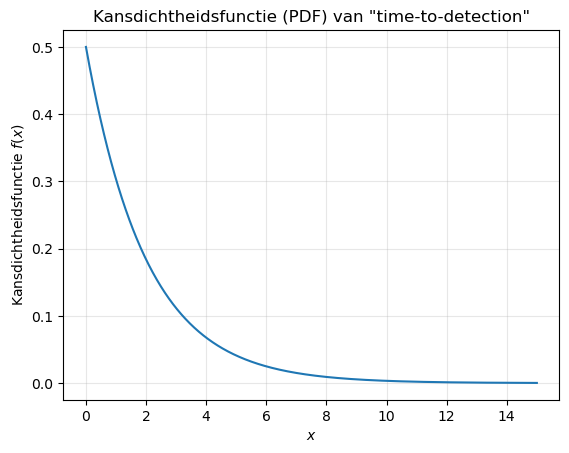

In [6]:
fig, ax = plt.subplots()

# x-axis
x = np.linspace(0, 15, 1_000)
y = 0.5 * np.exp(-0.5 * x)

ax.plot(x, y, color=colors[0])

ax.set_xlabel("$x$")
ax.set_ylabel("Kansdichtheidsfunctie $f(x)$")
ax.set_title('Kansdichtheidsfunctie (PDF) van "time-to-detection"')
ax.grid(True, alpha=0.3)
plt.savefig("./Figures/3_example_pdf.png")

# Hoe bereken je kansen voor continue kansvariabelen?

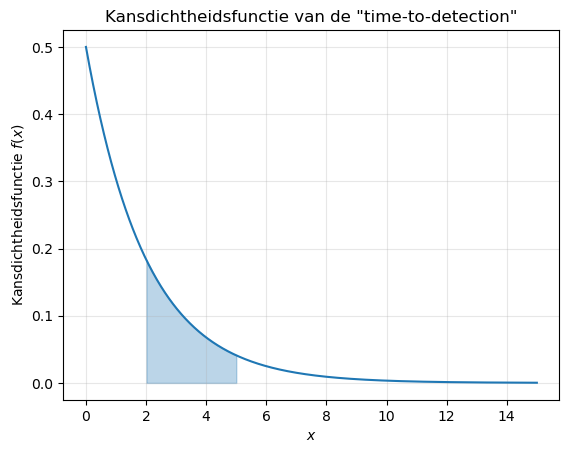

In [8]:
fig, ax = plt.subplots()

# x-axis
x = np.linspace(0, 15, 1_000)
y = 0.5 * np.exp(-0.5 * x)

ax.plot(x, y, color=colors[0])
ax.fill_between(x, y, where=((x>=2)&(x<=5)), ec=colors[0], color=colors[0], alpha=0.3)

ax.set_xlabel("$x$")
ax.set_ylabel("Kansdichtheidsfunctie $f(x)$")
ax.set_title('Kansdichtheidsfunctie van de "time-to-detection"')
ax.grid(True, alpha=0.3)
plt.savefig("./Figures/3_cont_prob.png")

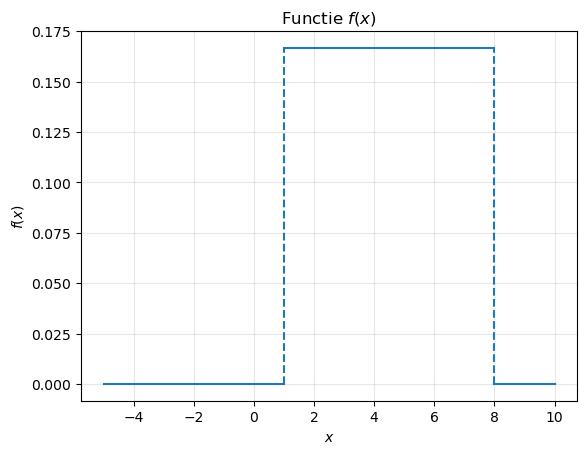

In [9]:
fig, ax = plt.subplots()

# x-axis
x = np.linspace(-5, 10, 1_000)

# Plot of function f(x) = 1/6 for 0 <= x <= 5, and 0 otherwise. This is NOT a pdf!
ax.plot([-5, 1], [0, 0], color=colors[0])
ax.plot([1, 8], [1/6, 1/6], color=colors[0])
ax.plot([8, 10], [0, 0], color=colors[0])

ax.plot([1, 1], [0, 1/6], color=colors[0], linestyle="dashed")
ax.plot([8, 8], [0, 1/6], color=colors[0], linestyle="dashed")

ax.set_xlabel("$x$")
ax.set_ylabel("$f(x)$")
ax.set_title('Functie $f(x)$')
ax.grid(True, alpha=0.3)

plt.savefig("./Figures/3_example_not_pdf.png")

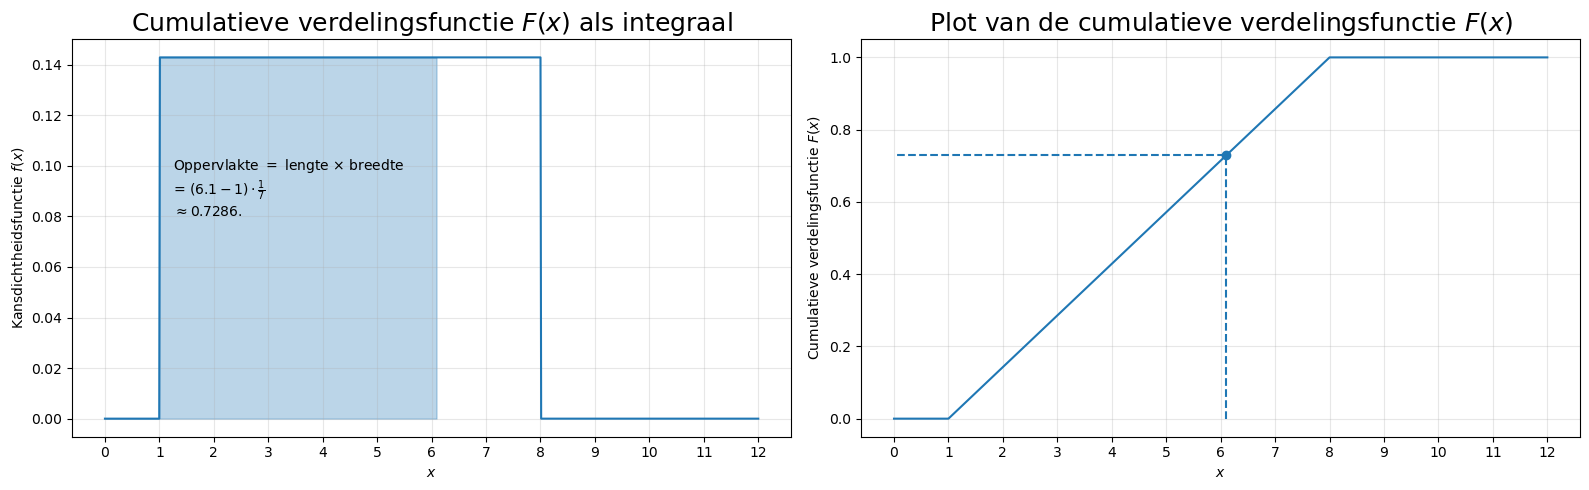

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

TARGET = 6.1

# x-axis
x = np.linspace(0, 12, 1_000)

mask = ((x>1)&(x<8))
y_pdf = uniform.pdf(x, loc=1, scale=7)
# y_pdf = weibull_min.pdf(x, c=2.1, scale=4)
axes[0].plot(x, y_pdf, color=colors[0])
axes[0].fill_between(x, y_pdf, where=((x>=0)&(x<=6.1)), ec=colors[0], color=colors[0], alpha=0.3)

axes[0].annotate("Oppervlakte $=$ lengte $\\times$ breedte \n= $(6.1 - 1) \\cdot \\frac{1}{7}$ \n$\\approx 0.7286$.", xy=(3.5, 0.08), xytext=(1.25, 0.08),
arrowprops=None)


axes[0].set_xlabel("$x$")
axes[0].set_ylabel("Kansdichtheidsfunctie $f(x)$")
axes[0].set_title('Cumulatieve verdelingsfunctie $F(x)$ als integraal', fontsize=18)
axes[0].set_xticks(np.arange(0, 13, 1))
axes[0].grid(True, alpha=0.3)


y_cdf = uniform.cdf(x, loc=1, scale=7) 
# y_cdf = weibull_min.cdf(x, c=2.1, scale=4)
axes[1].plot(x, y_cdf, color=colors[0])

axes[1].scatter([TARGET], [uniform.cdf(TARGET, loc=1, scale=7)])
axes[1].plot([TARGET, TARGET, 0], [0, uniform.cdf(TARGET, loc=1, scale=7), uniform.cdf(TARGET, loc=1, scale=7)], linestyle="dashed")


axes[1].set_xlabel("$x$")
axes[1].set_ylabel("Cumulatieve verdelingsfunctie $F(x)$")
axes[1].set_title('Plot van de cumulatieve verdelingsfunctie $F(x)$', fontsize=18)
axes[1].set_xticks(np.arange(0, 13, 1))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("./Figures/3_cumulative_distribution_function.png")

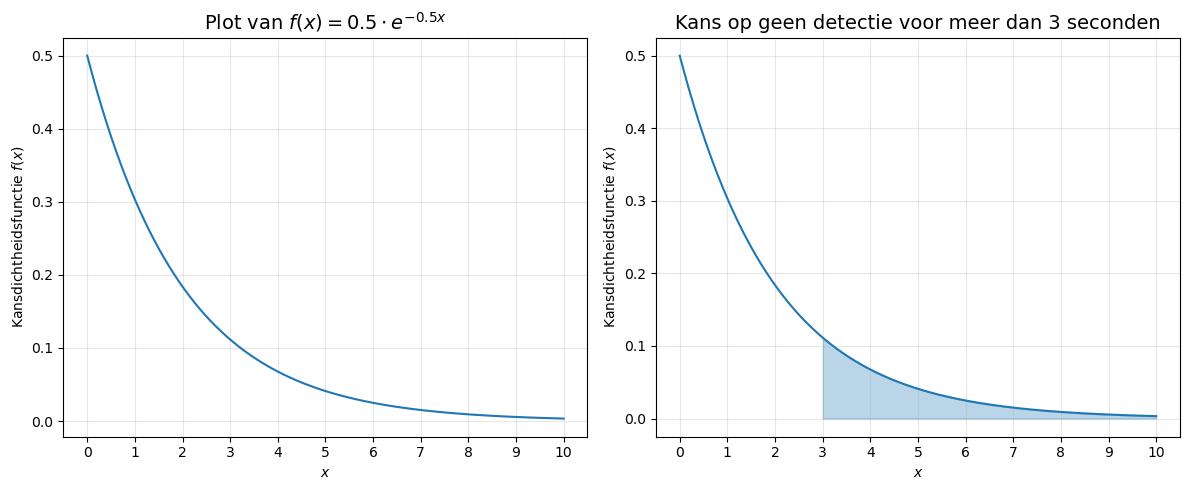

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# x-axis
x = np.linspace(0, 10, 1_000)
# y = 0.003 * (10 - x) ** 2
y = 0.5 * np.exp(-0.5 * x)

axes[0].plot(x, y, color=colors[0])
axes[0].set_xlabel("$x$")
axes[0].set_ylabel("Kansdichtheidsfunctie $f(x)$")
# axes[0].set_title('Plot van $f(x) = 0.003 \\cdot (10 - x)^2$', fontsize=14)
axes[0].set_title('Plot van $f(x) = 0.5 \\cdot e^{-0.5x}$', fontsize=14)
axes[0].set_xticks(np.arange(0, 11, 1))
axes[0].grid(True, alpha=0.3)

axes[1].plot(x, y, color=colors[0])
axes[1].fill_between(x, y, where=((x>=3)&(x<=10)), ec=colors[0], alpha=0.3)
axes[1].set_xlabel("$x$")
axes[1].set_ylabel("Kansdichtheidsfunctie $f(x)$")
axes[1].set_title('Kans op geen detectie voor meer dan 3 seconden', fontsize=14)
axes[1].set_xticks(np.arange(0, 11, 1))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("./Figures/3_example_exercise.png")

# Histogrammen met relatieve frequenties

[0.  0.  0.  0.  0.  0.  0.2 0.2 0.4 0.2] [  0.  10.  20.  30.  40.  50.  60.  70.  80.  90. 100.] <BarContainer object of 10 artists>


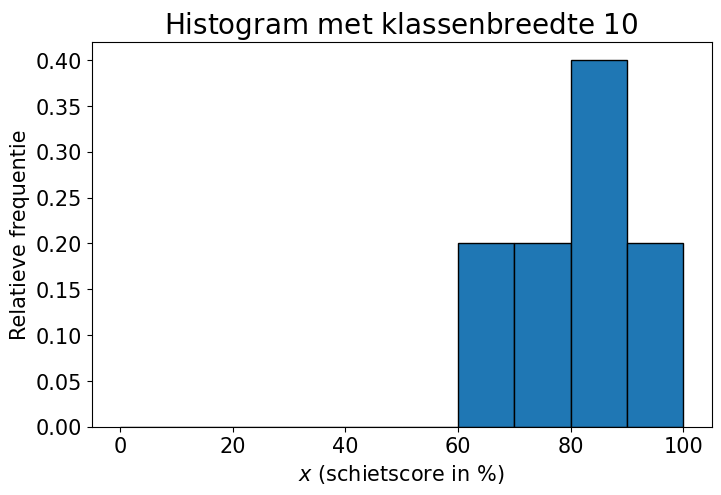

In [13]:
from scipy.stats import norm
np.random.seed(42)  # For reproducibility

x = np.linspace(0, 100, 100_000)

mu, sigma = 65, 10
samples = [85.3, 92.4, 78.1, 88.9, 65.3, 80.2, 90.1, 72.9, 70.3, 95.6, 82.1, 68.0, 88.7, 92.5, 60.2, 87.4, 75.7, 85.9, 80.1, 62.4]

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8,5))

n, bins, patches = axes.hist(samples, bins=np.arange(0, 101, 10), weights = [1/len(samples)] * len(samples), edgecolor=EDGE_COLOR)
print(n, bins, patches)

axes.set_title("Histogram met klassenbreedte $10$", fontsize=TITLE_FONT_SIZE)
axes.set_xlabel("$x$ (schietscore in %)", fontsize=AXIS_FONT_SIZE)
axes.set_ylabel("Relatieve frequentie", fontsize=AXIS_FONT_SIZE)
axes.tick_params(labelsize=15) 
    
plt.savefig("./Figures/3_histogram_relfreq_shooting_scores.png")

[0.00000e+00 2.00000e-06 2.10000e-04 6.12400e-03 6.04680e-02 2.42703e-01
 3.82507e-01 2.41378e-01 6.04290e-02 5.95800e-03] [  0.  10.  20.  30.  40.  50.  60.  70.  80.  90. 100.] <BarContainer object of 10 artists>


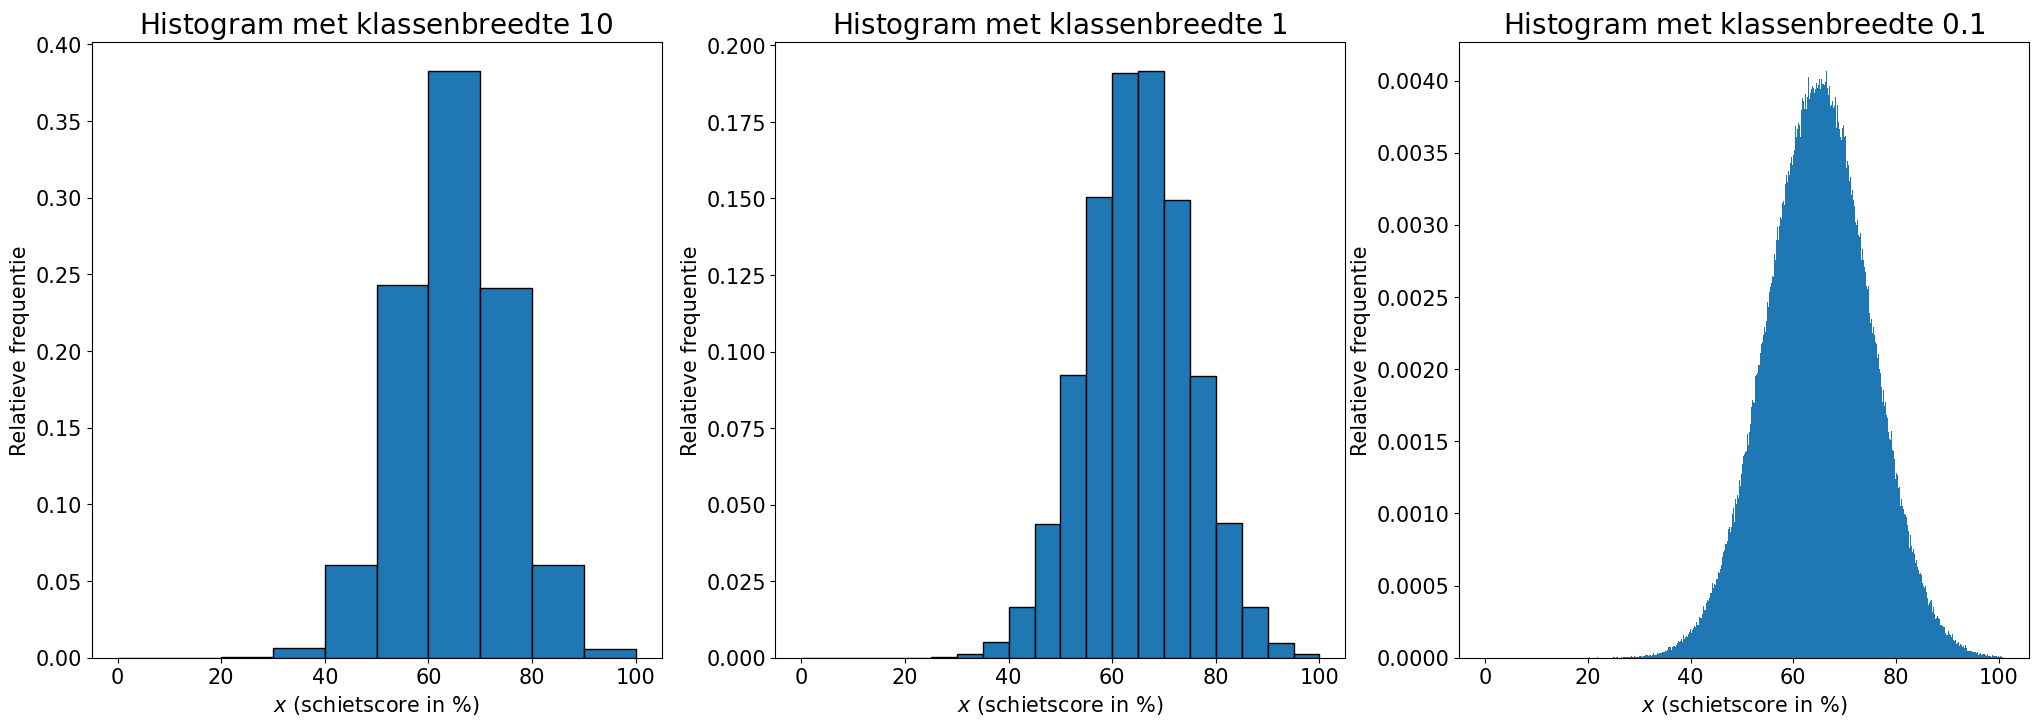

In [14]:
from scipy.stats import norm
np.random.seed(42)  # For reproducibility

x = np.linspace(0, 100, 100_000)

mu, sigma = 65, 10
samples = np.random.normal(mu, sigma, 1000000)

fig, axes = plt.subplots(1, 3, figsize=(25,8))

n, bins, patches = axes[0].hist(samples, bins=np.arange(0, 101, 10), edgecolor=EDGE_COLOR, weights = [1/len(samples)] * len(samples))
axes[0].set_title("Histogram met klassenbreedte $10$", fontsize=TITLE_FONT_SIZE)
print(n, bins, patches)

axes[1].hist(samples, bins=np.arange(0, 101, 5), edgecolor=EDGE_COLOR, weights = [1/len(samples)] * len(samples))
axes[1].set_title("Histogram met klassenbreedte $1$", fontsize=TITLE_FONT_SIZE)

axes[2].hist(samples, bins=np.arange(0, 101, 0.1), weights = [1/len(samples)] * len(samples))
axes[2].set_title("Histogram met klassenbreedte $0.1$", fontsize=TITLE_FONT_SIZE)

for i in range(3):
    axes[i].set_xlabel("$x$ (schietscore in %)", fontsize=AXIS_FONT_SIZE)
    axes[i].set_ylabel("Relatieve frequentie", fontsize=AXIS_FONT_SIZE)
    axes[i].tick_params(labelsize=15)
    
plt.savefig("./Figures/3_various_relfreq_histograms.png")

# Van histogrammen met relatieve frequenties naar dichtheid

[0.00000000e+00 2.00044210e-07 2.10046420e-05 6.12535370e-04
 6.04813664e-03 2.42756649e-02 3.82591553e-02 2.41431356e-02
 6.04423578e-03 5.95931701e-04] [  0.  10.  20.  30.  40.  50.  60.  70.  80.  90. 100.] <BarContainer object of 10 artists>


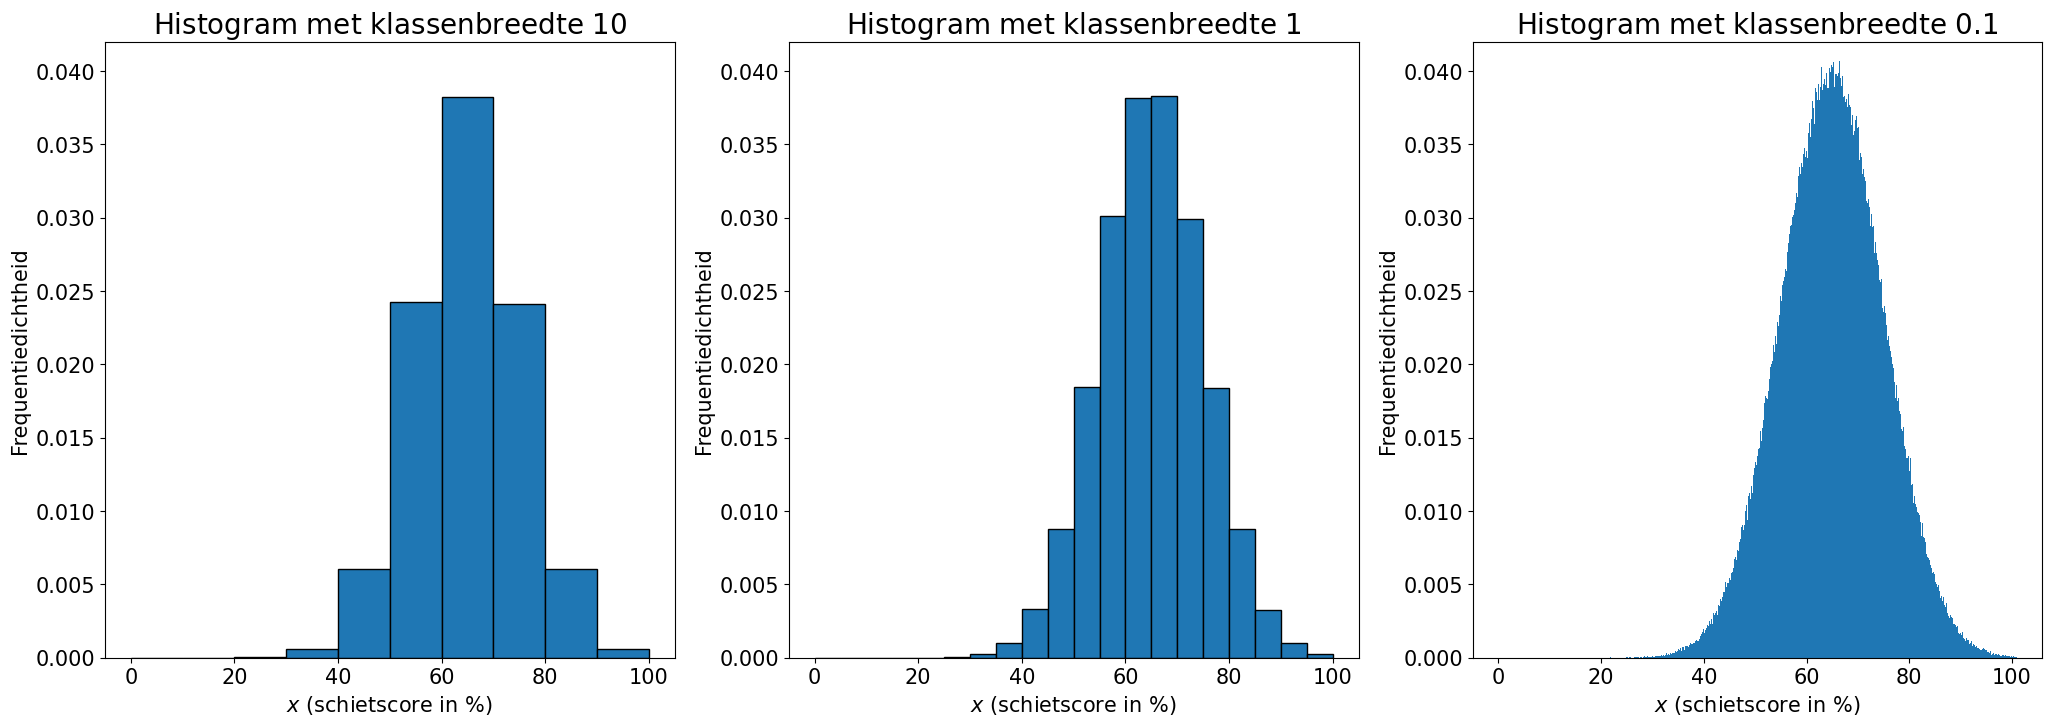

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(25,8))

n, bins, patches = axes[0].hist(samples, bins=np.arange(0, 101, 10), edgecolor=EDGE_COLOR, density=True)
axes[0].set_title("Histogram met klassenbreedte $10$", fontsize=TITLE_FONT_SIZE)
print(n, bins, patches)

axes[1].hist(samples, bins=np.arange(0, 101, 5), edgecolor=EDGE_COLOR, density=True)
axes[1].set_title("Histogram met klassenbreedte $1$", fontsize=TITLE_FONT_SIZE)

axes[2].hist(samples, bins=np.arange(0, 101, 0.1), density=True)
axes[2].set_title("Histogram met klassenbreedte $0.1$", fontsize=TITLE_FONT_SIZE)

for i in range(3):
    axes[i].set_xlabel("$x$ (schietscore in %)", fontsize=AXIS_FONT_SIZE)
    axes[i].set_ylabel("Frequentiedichtheid", fontsize=AXIS_FONT_SIZE)
    axes[i].set_ylim(0, 0.042)
    axes[i].tick_params(labelsize=15)
    
plt.savefig("./Figures/3_various_density_based_histograms.png")

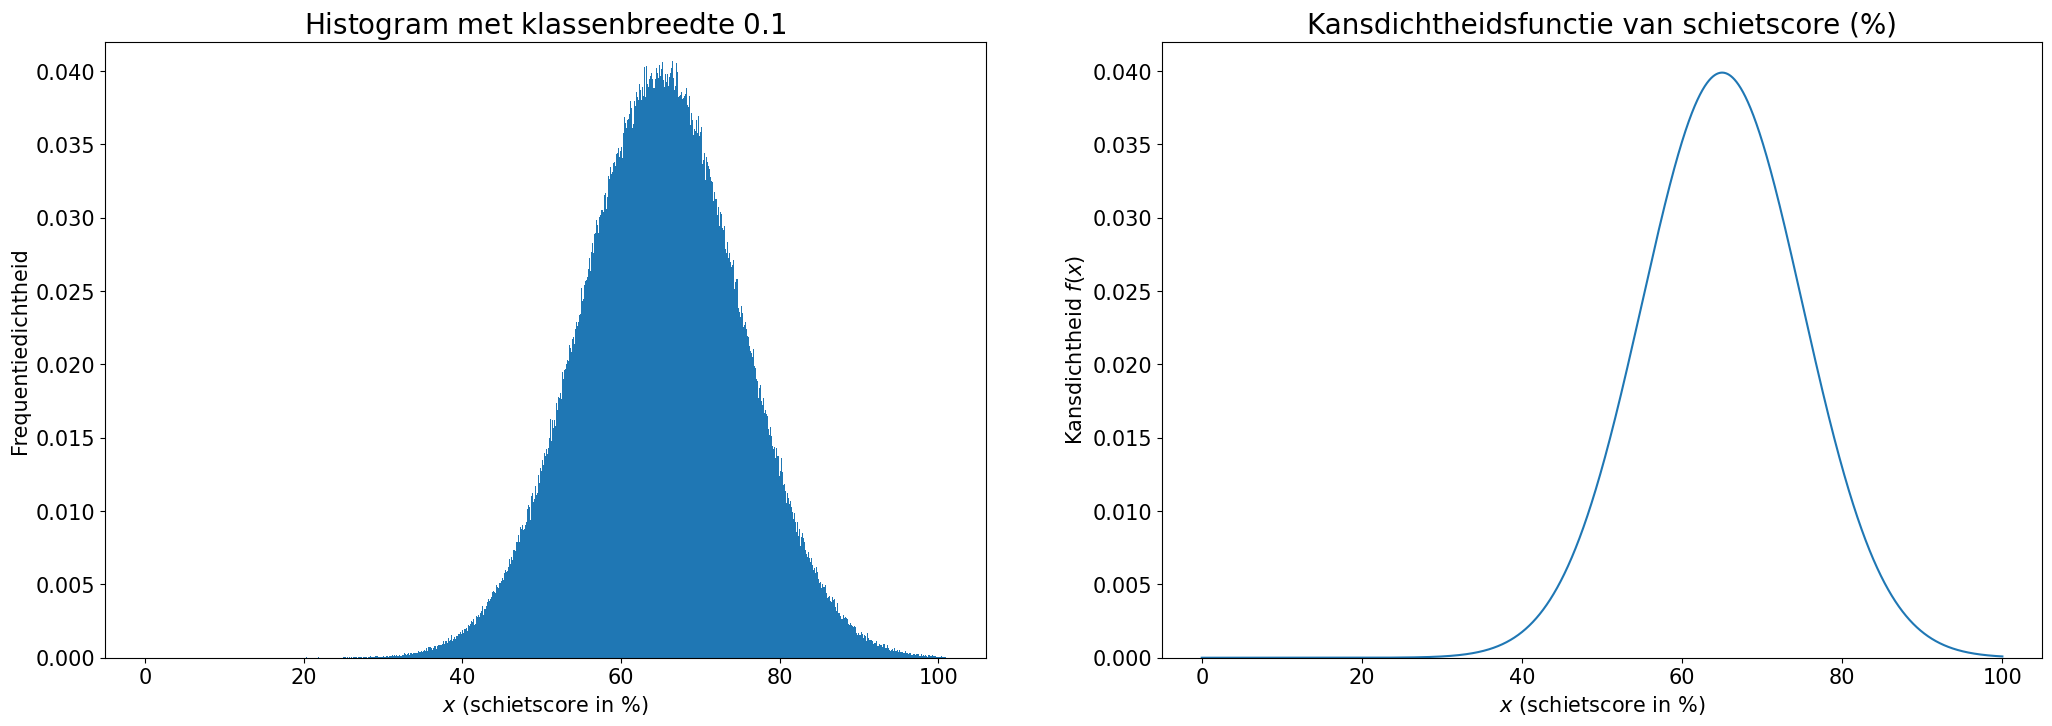

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(25,8))

axes[0].hist(samples, bins=np.arange(0, 101, 0.1), density=True)
axes[0].set_title("Histogram met klassenbreedte $0.1$", fontsize=TITLE_FONT_SIZE)


axes[1].plot(x, norm.pdf(x, mu, sigma))
axes[1].set_title("Kansdichtheidsfunctie van schietscore (%)", fontsize=TITLE_FONT_SIZE)


axes[0].set_ylabel("Frequentiedichtheid", fontsize=AXIS_FONT_SIZE)
axes[1].set_ylabel("Kansdichtheid $f(x)$", fontsize=AXIS_FONT_SIZE)

for i in range(2):
    axes[i].set_ylim(0, 0.042)
    axes[i].set_xlabel("$x$ (schietscore in %)", fontsize=AXIS_FONT_SIZE)
    axes[i].tick_params(labelsize=15)


plt.savefig("./Figures/3_from_hist_to_pdf.png")

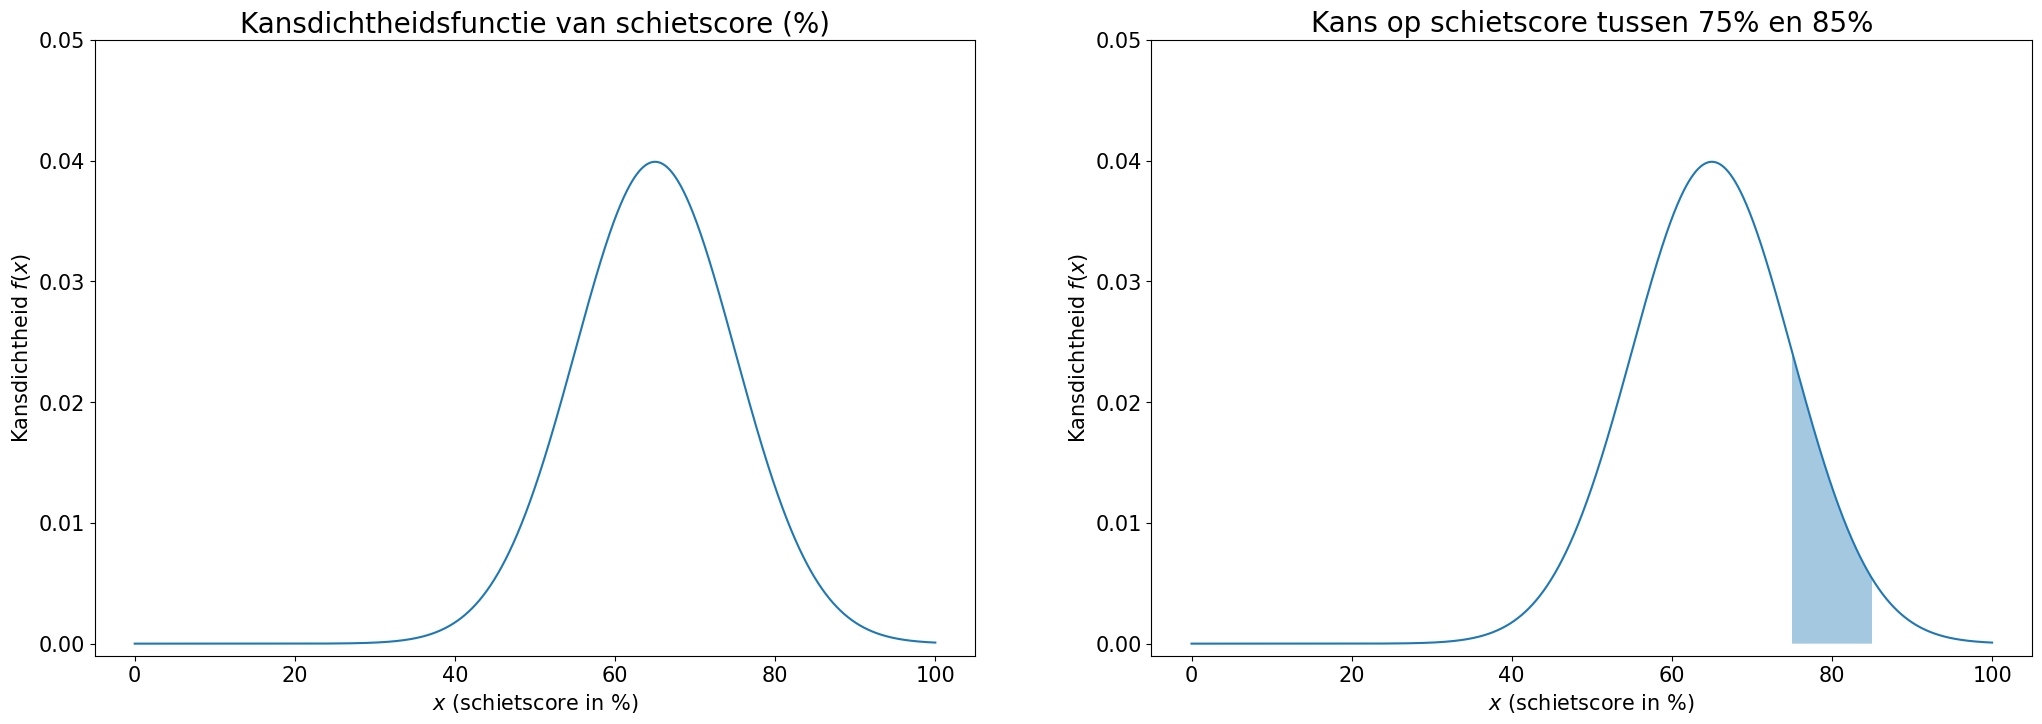

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(25,8))

pdf = norm.pdf(x, mu, sigma)
axes[0].plot(x, pdf)
axes[0].set_title("Kansdichtheidsfunctie van schietscore (%)", fontsize=TITLE_FONT_SIZE)

axes[1].plot(x, pdf)
axes[1].fill_between(x, pdf, 0, where=((x>75)&(x<85)), alpha=0.4)
axes[1].set_ylabel("Relatieve frequentie", fontsize=AXIS_FONT_SIZE)
axes[1].set_title("Kans op schietscore tussen 75% en 85%", fontsize=TITLE_FONT_SIZE)


for i in range(2):
    axes[i].set_ylim(-0.001, 0.05)
    axes[i].set_xlabel("$x$ (schietscore in %)", fontsize=AXIS_FONT_SIZE)
    axes[i].set_ylabel("Kansdichtheid $f(x)$", fontsize=AXIS_FONT_SIZE)
    axes[i].tick_params(labelsize=15)


plt.savefig("./Figures/3_pdf_prob.png")

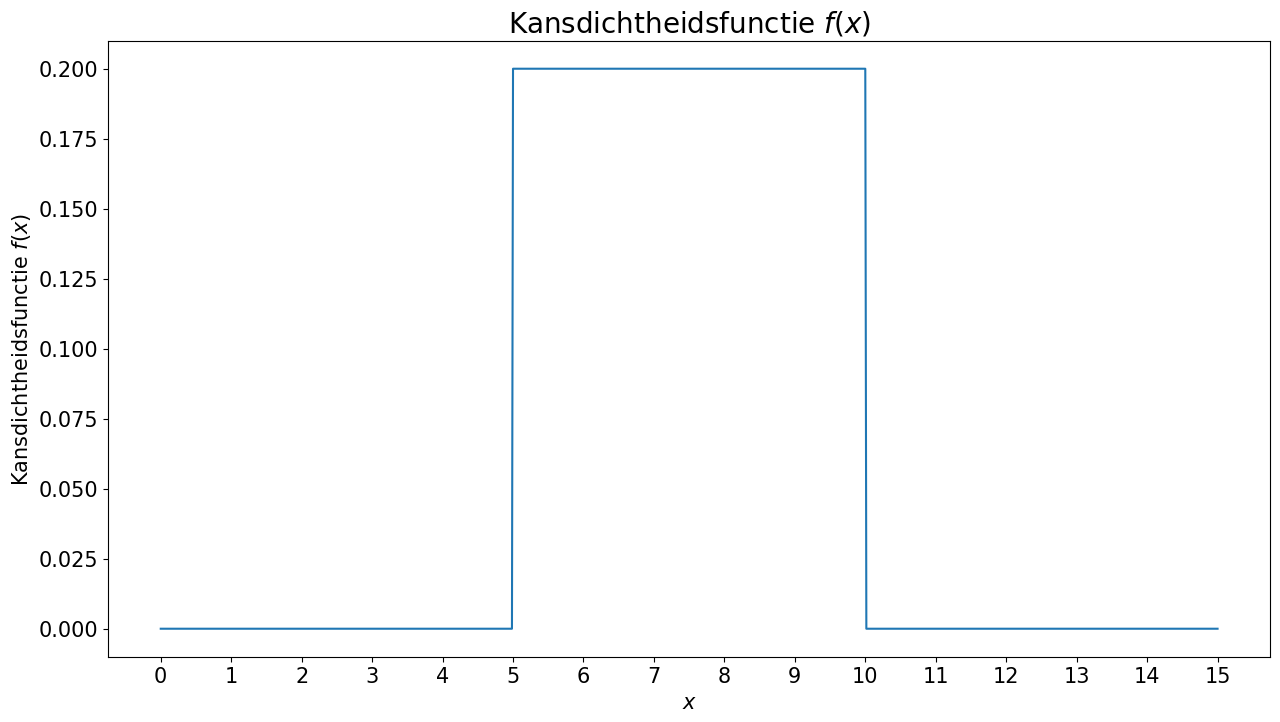

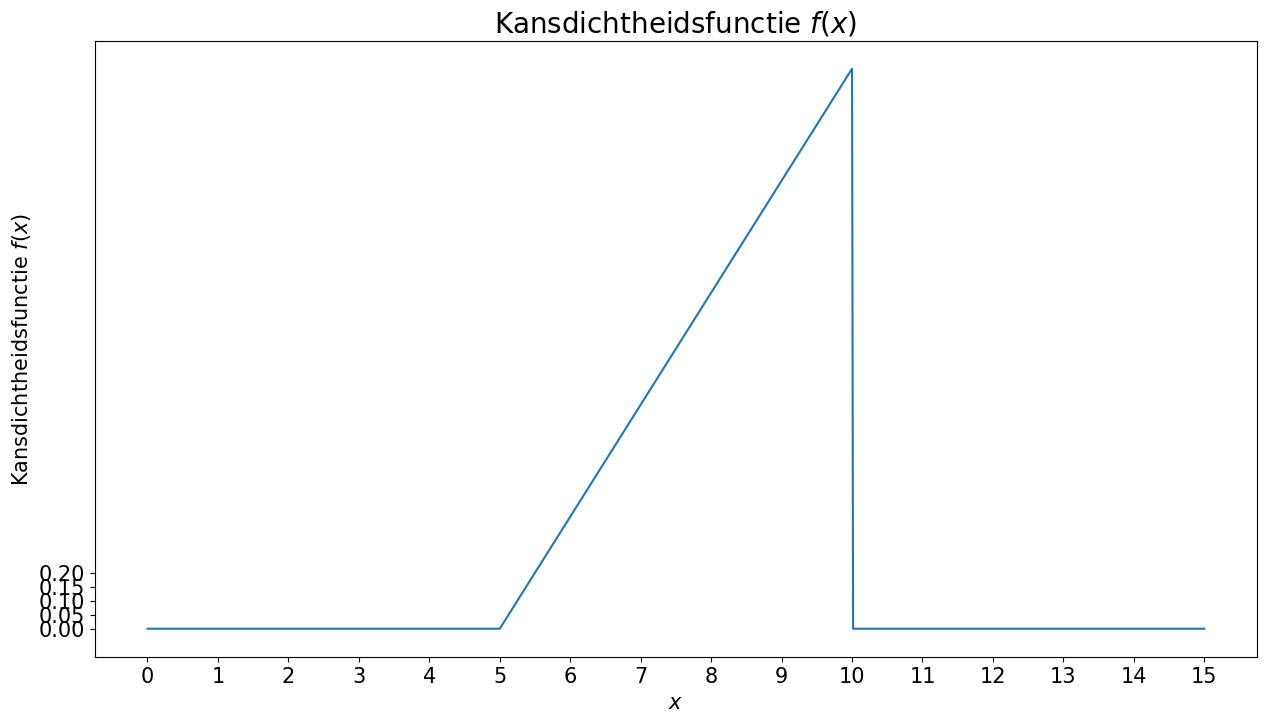

In [60]:
# FIRST OPTION
fig, ax = plt.subplots(figsize=(15,8))

x = np.linspace(0, 15, 1_000)

pdf1 = np.where((x >= 5) & (x <= 10), 0.2, 0)
pdf2 = np.where((x >= 5) & (x <= 10), 0.4*x - 2, 0)

ax.plot(x, pdf1)
ax.set_xlabel("$x$", fontsize=AXIS_FONT_SIZE)
ax.set_ylabel("Kansdichtheidsfunctie $f(x)$", fontsize=AXIS_FONT_SIZE)
ax.set_title("Kansdichtheidsfunctie $f(x)$", fontsize=TITLE_FONT_SIZE)
ax.tick_params(labelsize=AXIS_FONT_SIZE)
plt.xticks(np.arange(int(x.min()), int(x.max()) + 1))

plt.savefig("./Figures/opgave4.15a_1.png")


# SECOND OPTION
fig, ax = plt.subplots(figsize=(15,8))

ax.plot(x, pdf2)
ax.set_xlabel("$x$", fontsize=AXIS_FONT_SIZE)
ax.set_ylabel("Kansdichtheidsfunctie $f(x)$", fontsize=AXIS_FONT_SIZE)
ax.set_title("Kansdichtheidsfunctie $f(x)$", fontsize=TITLE_FONT_SIZE)
ax.tick_params(labelsize=AXIS_FONT_SIZE)
plt.xticks(np.arange(int(x.min()), int(x.max()) + 1))


plt.savefig("./Figures/opgave4.15a_2.png")